In [31]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

In [ ]:
C_ref  = 280 # ppm
lambd = 1.75 # W/m^2/K
beta = 5.35 # W/m^2/K
c_s = 4000* 50000 # J/kg/K
c_d = 4000* 50000 # J/kg/K
kappa = 0.1 
alpha = 0.29

In [152]:
np.log(1/2)

np.float64(-0.6931471805599453)

In [163]:
def dT_s_dt(t, T_s):
    return 1/c_s * (beta * np.log(560/C_ref) - lambd * T_s)

t = np.arange(0, 100, 1) * 86400 * 365 # time in seconds

results = spi.solve_ivp(dT_s_dt, [0, t[-1]], [0], t_eval=t)

In [164]:
results

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [         0   31536000 ... 3090528000 3122064000]
        y: [[ 0.000e+00  5.111e-01 ...  2.119e+00  2.119e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 158
     njev: 0
      nlu: 0

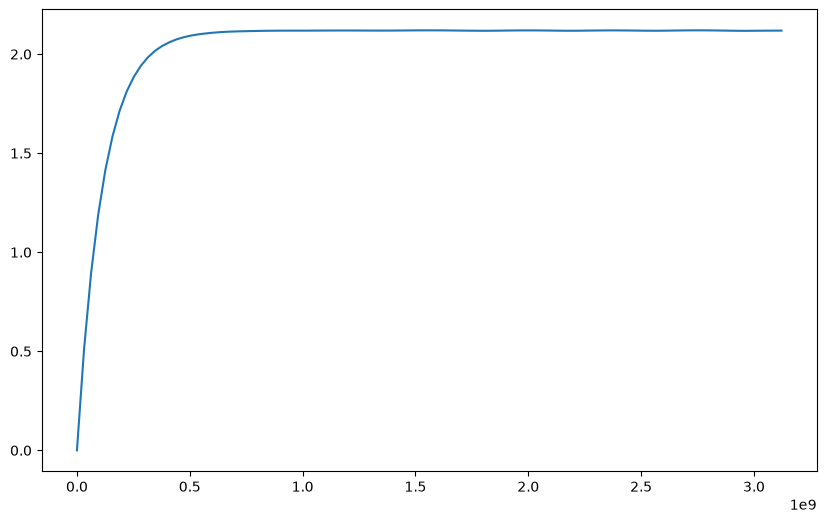

In [165]:
plt.figure(figsize=(10, 6))
plt.plot(results.t, results.y[0])

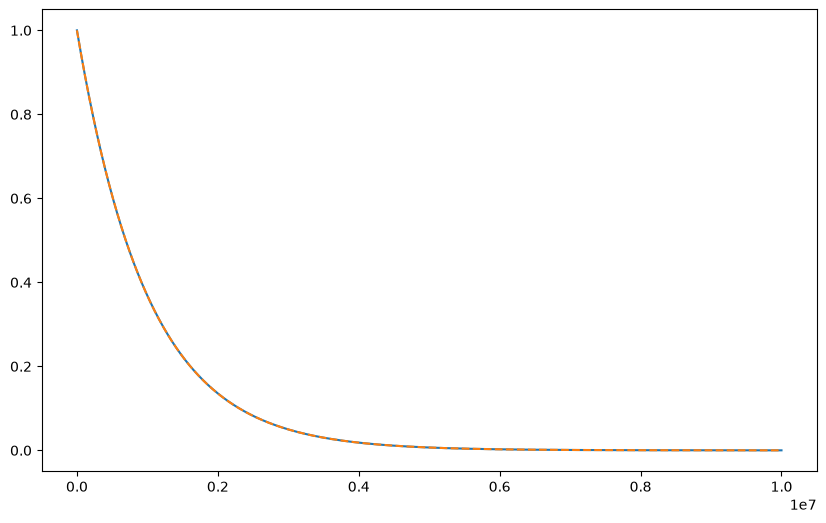

In [215]:
def dT(t, T):
    lambd = 1e-6 # 1/s
    return - lambd * T

t = np.arange(0, 10000000, 1) # time in seconds
results = spi.solve_ivp(dT, [t[0], t[-1]], [1], t_eval=t)

def T(t):
    C_0 = 1
    lambd = 1e-6 # 1/s
    return C_0 * np.exp(-lambd * t)

plt.figure(figsize=(10, 6))
plt.plot(results.t, results.y[0])
plt.plot(t, T(t), '--')

In [220]:
import numpy as np
from scipy.integrate import solve_ivp

# Parameters
cs = 4000.0 * 50 * 1000.0  # Heat capacity of the surface layer (J/m^2/K)
cd = 4000.0 * 3000.0 * 1000.0  # Heat capacity of the deep ocean layer (J/m^2/K)
lam = 1.75
etaH = 0.7
lam_star = 0.0
beta = 5.35
Ca0 = 280.0

def Ca(t):
    # Example forcing
    return 2 * 280#*np.exp(0.005*t)

def climate_rhs(t, y):
    Ts, Td = y

    forcing = beta*np.log(Ca(t)/Ca0)

    dTs = (
        -lam*Ts
        + forcing
        - (etaH + lam_star)*(Ts - Td)
    ) / cs

    dTd = etaH*(Ts - Td)/cd

    return [dTs, dTd]

y0 = [0.0, 0.0]

t = np.arange(0, 10000, 1) * 86400 * 365 # time in seconds

sol = solve_ivp(
    climate_rhs,
    (0, t[-1]),
    y0,
    method='RK45',
    t_eval=t
)

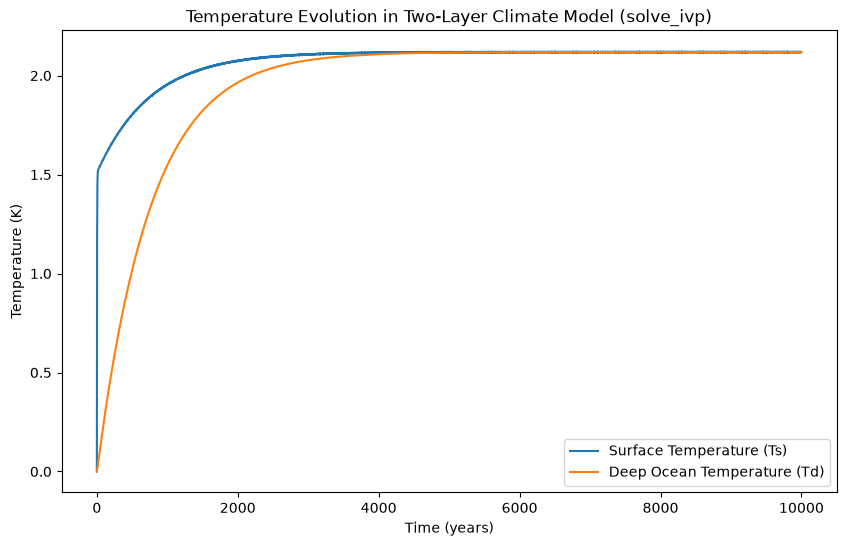

In [229]:
plt.figure(figsize=(10, 6))
plt.plot(sol.t / (86400 * 365), sol.y[0], label='Surface Temperature (Ts)')
plt.plot(sol.t / (86400 * 365), sol.y[1], label='Deep Ocean Temperature (Td)')
plt.xlabel('Time (years)')
plt.ylabel('Temperature (K)')
plt.title('Temperature Evolution in Two-Layer Climate Model (solve_ivp)')
plt.legend()

In [222]:
# Time array (seconds)
t = np.arange(0, 10000, 1) * 86400 * 365
dt = t[1] - t[0]

# Allocate solution arrays
Ts = np.zeros(len(t))
Td = np.zeros(len(t))

# Initial conditions
Ts[0] = 0.0
Td[0] = 0.0

# Time stepping
for n in range(len(t)-1):

    forcing = beta * np.log(Ca(t[n]) / Ca0)

    dTs = (
        -lam * Ts[n]
        + forcing
        - (etaH + lam_star) * (Ts[n] - Td[n])
    ) / cs

    dTd = etaH * (Ts[n] - Td[n]) / cd

    # Euler update
    Ts[n+1] = Ts[n] + dt * dTs
    Td[n+1] = Td[n] + dt * dTd

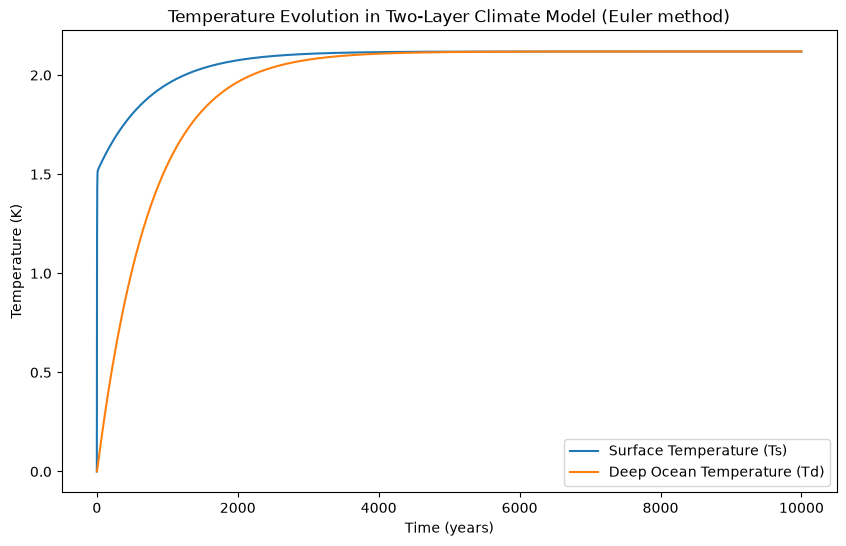

In [230]:
plt.figure(figsize=(10, 6))
plt.plot(t / (86400 * 365), Ts, label='Surface Temperature (Ts)')
plt.plot(t / (86400 * 365), Td, label='Deep Ocean Temperature (Td)')
plt.xlabel('Time (years)')
plt.ylabel('Temperature (K)')
plt.title('Temperature Evolution in Two-Layer Climate Model (Euler method)')
plt.legend()